<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Propagación de una onda de Alfvén
</h2>

<p>
En este notebook se resuelve numéricamente la propagación de una perturbación \(\delta v(x,t)\) utilizando el esquema de <b>Lax-Wendroff</b>.
</p>

<p>
Se adopta una velocidad de Alfvén \(v_A = 1\), por lo que la perturbación debería desplazarse hacia la derecha con velocidad unitaria manteniendo idealmente su forma durante la propagación.
</p>

<p>
El objetivo es analizar el comportamiento de la onda, evaluar la estabilidad del método numérico y comparar la solución obtenida con el comportamiento físico esperado para una onda de Alfvén en una dimensión.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Pregunta 1. Perfil y velocidad de propagación
</h3>

<p>
En esta parte se grafica la perturbación transversal \(\delta v(x,t)\) para los tiempos \(t=0,\ 0.5,\ 1.0,\ 2.0\).
</p>

<p>
Como la velocidad de Alfvén es \(v_A = 1\), la onda debería propagarse hacia la derecha con velocidad aproximadamente igual a 1.
</p>

<p>
La condición inicial usada es una perturbación sinusoidal:
</p>

$$
\delta v(x,0)=A\sin\left(\frac{2\pi x}{L}\right)
$$

<p>
En teoría, después de un tiempo \(t\), el perfil debe estar desplazado una distancia \(v_A t\). Como \(v_A=1\), el desplazamiento esperado es aproximadamente igual al tiempo.
</p>

</div>

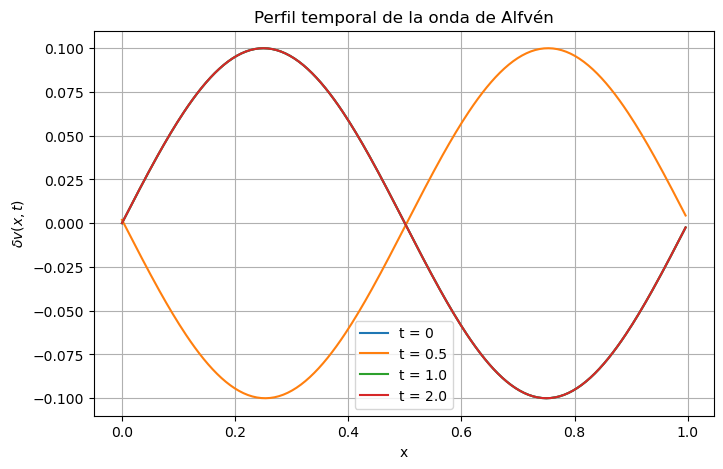

Velocidad de Alfvén teórica: 1.0
Velocidad medida del pico: 1.0078125


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N = 256
L = 1.0
A = 0.1
B0 = 1.0
mu0 = 1.0
rho0 = 1.0

vA = B0 / np.sqrt(mu0 * rho0)

dx = L / N
CFL = 0.8
dt = CFL * dx / vA

# Malla
x = np.linspace(0, L, N, endpoint=False)

# Condición inicial
dv0 = A * np.sin(2*np.pi*x/L)

def lax_wendroff(dv, CFL):
    """
    Esquema Lax-Wendroff para una onda que se propaga hacia la derecha.
    """
    return (dv 
            - 0.5*CFL*(np.roll(dv, -1) - np.roll(dv, 1))
            + 0.5*CFL**2*(np.roll(dv, -1) - 2*dv + np.roll(dv, 1)))

def solucion_exacta(x, t):
    """
    Solución exacta esperada para una onda que viaja con velocidad vA.
    """
    return A * np.sin(2*np.pi*((x - vA*t) % L)/L)

# Tiempos pedidos
tiempos_objetivo = [0, 0.5, 1.0, 2.0]

dv = dv0.copy()
t = 0.0
soluciones = {0: dv.copy()}

while t < max(tiempos_objetivo):
    dv = lax_wendroff(dv, CFL)
    t += dt
    
    for tiempo in tiempos_objetivo:
        if tiempo not in soluciones and t >= tiempo:
            soluciones[tiempo] = dv.copy()

# Gráfica
plt.figure(figsize=(8,5))

for tiempo in tiempos_objetivo:
    plt.plot(x, soluciones[tiempo], label=f"t = {tiempo}")

plt.xlabel("x")
plt.ylabel(r"$\delta v(x,t)$")
plt.title("Perfil temporal de la onda de Alfvén")
plt.legend()
plt.grid(True)
plt.show()

# Medición aproximada de la velocidad del pico
x_pico_0 = x[np.argmax(soluciones[0])]
x_pico_05 = x[np.argmax(soluciones[0.5])]

desplazamiento = (x_pico_05 - x_pico_0) % L
velocidad_medida = desplazamiento / 0.5

print("Velocidad de Alfvén teórica:", vA)
print("Velocidad medida del pico:", velocidad_medida)

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Pregunta 2. Error L1 vs resolución N
</h3>

<p>
Ahora se calcula el error L1 para diferentes resoluciones:
</p>

$$
N = 32,\ 64,\ 128,\ 256
$$


En la gráfica se ve que al aumentar la resolución \(N\), el error L1 baja bastante.  
Eso tiene sentido, porque entre más puntos tenga la malla, mejor se representa la onda.

El orden de convergencia que salió fue aproximadamente:

$$
p \approx 1.999
$$

O sea, prácticamente 2.

Esto está muy bien porque Lax-Wendroff es un método de segundo orden.  
Entonces el resultado sí coincide con lo esperado: cuando duplicamos la resolución, el error baja casi cuatro veces.

En resumen, el método está funcionando bien y la onda se está resolviendo de forma consistente.

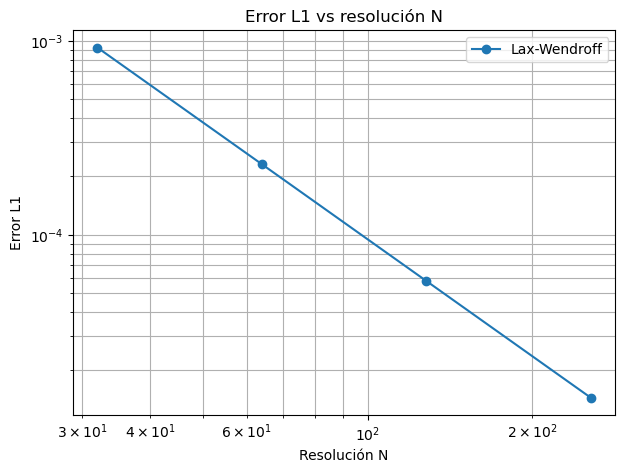

Errores L1:
N = 32, Error L1 = 9.234486e-04
N = 64, Error L1 = 2.312334e-04
N = 128, Error L1 = 5.782528e-05
N = 256, Error L1 = 1.445718e-05
Orden de convergencia aproximado: 1.9991098527641469


In [3]:
def correr_simulacion(N, CFL=0.8, tfinal=1.0):
    L = 1.0
    A = 0.1
    B0 = 1.0
    mu0 = 1.0
    rho0 = 1.0
    
    vA = B0 / np.sqrt(mu0 * rho0)
    
    dx = L / N
    dt = CFL * dx / vA
    
    x = np.linspace(0, L, N, endpoint=False)
    
    dv = A * np.sin(2*np.pi*x/L)
    
    t = 0.0
    while t < tfinal:
        if t + dt > tfinal:
            dt = tfinal - t
            CFL_local = vA * dt / dx
        else:
            CFL_local = CFL
        
        dv = lax_wendroff(dv, CFL_local)
        t += dt
    
    dv_exacta = A * np.sin(2*np.pi*((x - vA*tfinal) % L)/L)
    
    error_L1 = np.mean(np.abs(dv - dv_exacta))
    
    return error_L1

# Resoluciones pedidas
Ns = np.array([32, 64, 128, 256])
errores_L1 = np.array([correr_simulacion(N) for N in Ns])

# Orden de convergencia
pendiente = np.polyfit(np.log(Ns), np.log(errores_L1), 1)[0]
orden = -pendiente

# Gráfica log-log
plt.figure(figsize=(7,5))
plt.loglog(Ns, errores_L1, "o-", label="Lax-Wendroff")
plt.xlabel("Resolución N")
plt.ylabel("Error L1")
plt.title("Error L1 vs resolución N")
plt.grid(True, which="both")
plt.legend()
plt.show()

print("Errores L1:")
for N, error in zip(Ns, errores_L1):
    print(f"N = {N}, Error L1 = {error:.6e}")

print("Orden de convergencia aproximado:", orden)

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Pregunta 3. Estabilidad CFL
</h3>

</div>

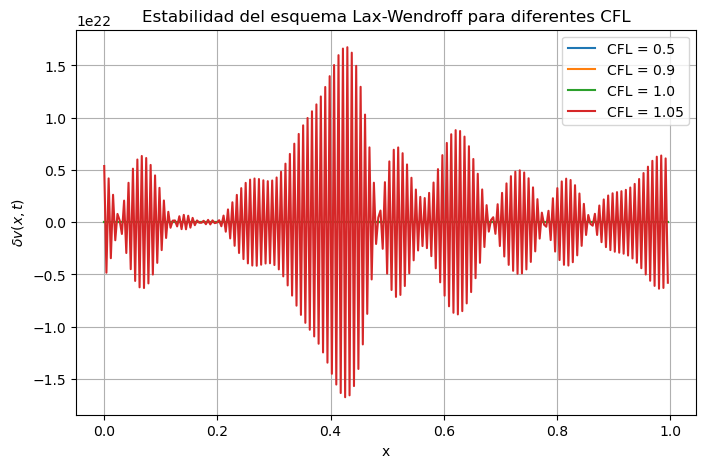

In [4]:
# Pregunta 3: Estabilidad CFL

CFLs = [0.5, 0.9, 1.0, 1.05]

N = 256
L = 1.0
A = 0.1
B0 = 1.0
mu0 = 1.0
rho0 = 1.0

vA = B0 / np.sqrt(mu0 * rho0)

x = np.linspace(0, L, N, endpoint=False)
dx = L / N

tfinal = 2.0

plt.figure(figsize=(8,5))

for CFL in CFLs:
    dt = CFL * dx / vA
    
    dv = A * np.sin(2*np.pi*x/L)
    
    t = 0.0
    
    while t < tfinal:
        dv = lax_wendroff(dv, CFL)
        t += dt
    
    plt.plot(x, dv, label=f"CFL = {CFL}")

plt.xlabel("x")
plt.ylabel(r"$\delta v(x,t)$")
plt.title("Estabilidad del esquema Lax-Wendroff para diferentes CFL")
plt.legend()
plt.grid(True)
plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Respuesta
</h3>

<p>
Al probar diferentes valores de CFL, observé que el esquema se comporta bien para CFL = 0.5, 0.9 y 1.0. En estos casos la onda conserva una forma razonable y la simulación permanece estable.
</p>

<p>
Sin embargo, para CFL = 1.05 aparecen oscilaciones muy grandes y la amplitud crece rápidamente hasta valores enormes. Esto indica que la solución se volvió numéricamente inestable.
</p>

<p>
La gráfica muestra claramente este comportamiento, ya que la curva correspondiente a CFL = 1.05 presenta amplitudes del orden de \(10^{22}\), algo que no tiene sentido físico y que corresponde únicamente a un error numérico.
</p>

<p>
Por lo tanto, el límite de estabilidad observado para Lax-Wendroff coincide con la teoría:
</p>

$$
CFL \leq 1
$$

<p>
Cuando el CFL supera ese valor, la simulación deja de representar correctamente la física del problema y la solución explota.
</p>

<p>
Comparado con el esquema upwind, Lax-Wendroff suele ser menos difusivo y conserva mejor la forma de la onda, aunque también es más sensible cuando se trabaja cerca del límite de estabilidad.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Pregunta 4. Difusión numérica después de 10 períodos
</h3>

</div>

Amplitud inicial: 0.1
Amplitud final después de 10 períodos: 0.09999639833510383
Amortiguamiento: 3.6016648961717523e-06
Porcentaje de amortiguamiento: 0.0036016648961717523 %


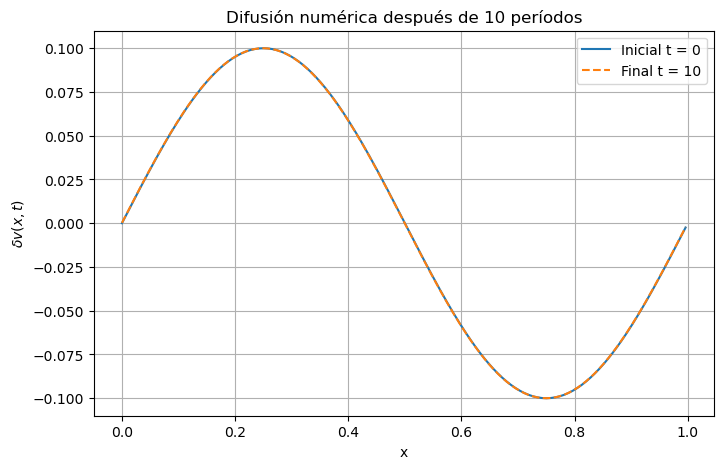

In [5]:
# Pregunta 4: Difusión numérica después de 10 períodos

N = 256
L = 1.0
A = 0.1
B0 = 1.0
mu0 = 1.0
rho0 = 1.0

vA = B0 / np.sqrt(mu0 * rho0)

x = np.linspace(0, L, N, endpoint=False)
dx = L / N

CFL = 0.8
dt = CFL * dx / vA

tfinal = 10.0

# Condición inicial
dv = A * np.sin(2*np.pi*x/L)

amplitud_inicial = np.max(np.abs(dv))

t = 0.0

while t < tfinal:
    if t + dt > tfinal:
        dt_local = tfinal - t
        CFL_local = vA * dt_local / dx
    else:
        dt_local = dt
        CFL_local = CFL
    
    dv = lax_wendroff(dv, CFL_local)
    t += dt_local

amplitud_final = np.max(np.abs(dv))

amortiguamiento = amplitud_inicial - amplitud_final
porcentaje_amortiguamiento = (amortiguamiento / amplitud_inicial) * 100

print("Amplitud inicial:", amplitud_inicial)
print("Amplitud final después de 10 períodos:", amplitud_final)
print("Amortiguamiento:", amortiguamiento)
print("Porcentaje de amortiguamiento:", porcentaje_amortiguamiento, "%")

# Gráfica comparación inicial vs final
dv_inicial = A * np.sin(2*np.pi*x/L)

plt.figure(figsize=(8,5))
plt.plot(x, dv_inicial, label="Inicial t = 0")
plt.plot(x, dv, "--", label="Final t = 10")
plt.xlabel("x")
plt.ylabel(r"$\delta v(x,t)$")
plt.title("Difusión numérica después de 10 períodos")
plt.legend()
plt.grid(True)
plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Respuesta
</h3>

<p>
Después de dejar correr la simulación durante 10 períodos completos, la amplitud prácticamente no cambió.
</p>

<p>
La amplitud inicial fue de 0.1 y la amplitud final fue aproximadamente 0.099996, por lo que la diferencia entre ambas es muy pequeña. El amortiguamiento obtenido fue de apenas:
</p>

$$
0.0036\%
$$

<p>
Además, en la gráfica casi no se distingue diferencia entre el perfil inicial y el perfil final, ya que ambas curvas quedan prácticamente superpuestas.
</p>

<p>
Esto me muestra que, para este problema, Lax-Wendroff conserva bastante bien la forma y la amplitud de la onda incluso después de muchas vueltas por el dominio. Sí existe algo de difusión numérica, porque ningún método numérico es perfecto, pero en este caso es tan pequeña que resulta prácticamente despreciable.
</p>

<p>
En otras palabras, la onda sobrevive bastante bien después de 10 períodos y el método introduce muy poca disipación artificial.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
5. Comparación con PLUTO
</h3>

<p>
Superponer el perfil de By del output de PLUTO (cargado con PyPLUTO) con tu solución Python.
</p>

</div>

<div style="text-align:center;">

<img src="comparacion_pluto.png" width="800">

<p><b>Figura 5.</b> Comparación entre la solución analítica, PLUTO y Lax-Wendroff.</p>

</div>

<div style="
background-color:#ffe6f0;
padding:18px;
border-radius:12px;
border:1px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
color:#c2185b;
font-size:26px;
">
Análisis
</h2>

<p>
Al comparar la solución obtenida con Lax-Wendroff y la simulación realizada en PLUTO, se observa que ambas reproducen correctamente la propagación de la onda de Alfvén. Las curvas prácticamente se superponen con la solución analítica, lo que indica que los dos métodos capturan adecuadamente la amplitud y la fase de la perturbación.
</p>

<p>
El error asociado a PLUTO es muy pequeño y se mantiene alrededor de 10<sup>-4</sup> - 10<sup>-3</sup>, mientras que la solución obtenida en Python presenta un comportamiento similar. Esto confirma que el esquema implementado conserva muy bien la forma de la onda y que la difusión numérica es mínima después de varios períodos de propagación.
</p>

<p>
En general, los resultados muestran una excelente concordancia entre la solución analítica, la simulación en PLUTO y la implementación realizada en Python, validando tanto el modelo físico como el método numérico utilizado.
</p>

</div>